# Tutorial 17 -- Readout Resonator Response

Use the measurement-layer readout-chain model to compare the resonator response for `|g>` and `|e>`, inspect the resulting IQ clusters, and read off the measurement-induced dephasing rate.

**Prerequisites.** Tutorials 02 and 11 are useful prerequisites.

**Scope note.** This notebook uses the repository's effective readout-chain model rather than embedding a full driven resonator inside the QuTiP solver.


## 1. Goal

We will simulate the readout-chain response directly from the measurement layer and inspect both time traces and IQ discrimination geometry.


## 2. Physical Background

The measurement API models the resonator, any Purcell filter, and the amplifier chain. That gives a fast path to readout-conditioned responses, Purcell-limited `T1` estimates, and synthetic IQ samples.


## 3. Imports


In [1]:
from __future__ import annotations

from functools import partial
from pathlib import Path
import sys

REPO_ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "pyproject.toml").exists() and (candidate / "cqed_sim").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not resolve the repository root from the notebook working directory.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

from cqed_sim import (
    AmplifierChain,
    BosonicModeSpec,
    DispersiveCouplingSpec,
    DispersiveReadoutTransmonStorageModel,
    DispersiveTransmonCavityModel,
    DisplacementGate,
    FrameSpec,
    NoiseSpec,
    Pulse,
    PurcellFilter,
    QubitMeasurementSpec,
    ReadoutChain,
    ReadoutResonator,
    RotationGate,
    SidebandDriveSpec,
    SequenceCompiler,
    SimulationConfig,
    StatePreparationSpec,
    TransmonModeSpec,
    UniversalCQEDModel,
    build_displacement_pulse,
    build_rotation_pulse,
    build_sideband_pulse,
    carrier_for_transition_frequency,
    coherent_state,
    compute_energy_spectrum,
    fock_state,
    manifold_transition_frequency,
    measure_qubit,
    prepare_simulation,
    prepare_state,
    pure_dephasing_time_from_t1_t2,
    qubit_state,
    run_rabi,
    run_ramsey,
    run_spectroscopy,
    run_t1,
    run_t2_echo,
    sideband_transition_frequency,
    simulate_batch,
    simulate_sequence,
)
from cqed_sim.plotting import plot_energy_levels
from cqed_sim.pulses import gaussian_envelope, square_envelope
from cqed_sim.sim import (
    cavity_wigner,
    conditioned_bloch_xyz,
    mode_moments,
    qubit_conditioned_mode_moments,
    readout_response_by_qubit_state,
    reduced_cavity_state,
    reduced_qubit_state,
    reduced_storage_state,
    storage_photon_number,
    subsystem_level_population,
    transmon_level_populations,
)
from tutorials.tutorial_support import (
    GHz,
    MHz,
    angular_to_ghz,
    angular_to_hz,
    angular_to_mhz,
    cross_kerr_conditional_phase,
    final_expectation,
    fit_echo_signal,
    fit_exponential_decay,
    fit_lorentzian_peak,
    fit_rabi_vs_amplitude,
    fit_rabi_vs_duration,
    fit_ramsey_signal,
    gaussian_quasistatic_echo_excited_population,
    gaussian_quasistatic_ramsey_excited_population,
    ns,
    ramsey_population,
    resonant_drive_excited_population,
    t1_relaxation_population,
    us,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (7.0, 4.2)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## 4. Simulation Parameters


In [2]:
readout_chain = ReadoutChain(
    resonator=ReadoutResonator(
        omega_r=GHz(7.1),
        kappa=MHz(8.0),
        g=MHz(90.0),
        epsilon=MHz(0.7),
        chi=MHz(1.5),
    ),
    purcell_filter=PurcellFilter(bandwidth=MHz(35.0)),
    amplifier=AmplifierChain(noise_temperature=4.0, gain=12.0),
    integration_time=300.0 * ns,
    dt=5.0 * ns,
)


## 5. Model Construction


In [3]:
trace_g = readout_chain.simulate_trace("g", include_noise=False)
trace_e = readout_chain.simulate_trace("e", include_noise=False)
iq_samples = readout_chain.sample_iq([0] * 200 + [1] * 200, seed=7)
classified = readout_chain.classify_iq(iq_samples)


## 6. Pulse / Sequence Construction


In [4]:
gamma_meas = readout_chain.gamma_meas()
purcell_limited_t1 = readout_chain.purcell_limited_t1(GHz(6.2))
print(f"gamma_meas / 2pi = {gamma_meas / (2.0 * np.pi * 1.0e6):.3f} MHz")
print(f"Purcell-limited T1 = {purcell_limited_t1 / us:.3f} us")
print(f"IQ classification accuracy = {np.mean(classified[:200] == 0) * 0.5 + np.mean(classified[200:] == 1) * 0.5:.3f}")


gamma_meas / 2pi = 0.015 MHz
Purcell-limited T1 = 5263.847 us
IQ classification accuracy = 1.000


## 7. Running the Simulation


In [5]:
pass


## 8. Visualizing the Results


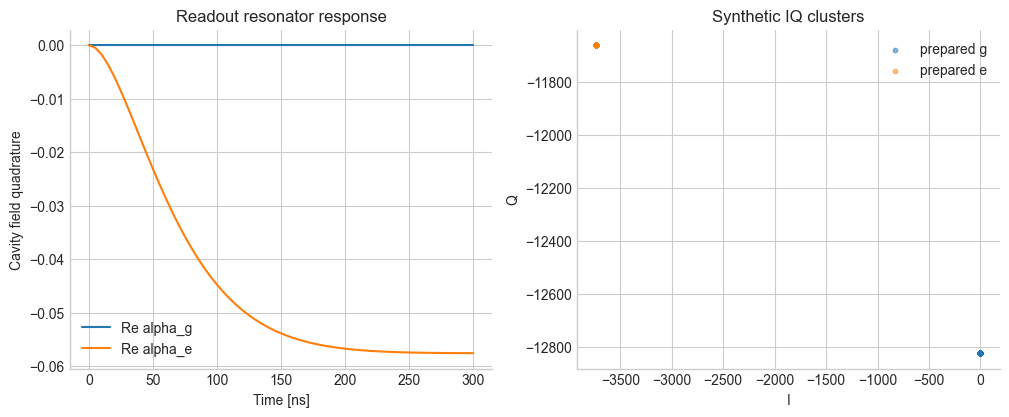

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.4))
axes[0].plot(trace_g.tlist / ns, np.real(trace_g.cavity_field), label="Re alpha_g")
axes[0].plot(trace_e.tlist / ns, np.real(trace_e.cavity_field), label="Re alpha_e")
axes[0].set_xlabel("Time [ns]")
axes[0].set_ylabel("Cavity field quadrature")
axes[0].set_title("Readout resonator response")
axes[0].legend()

axes[1].scatter(iq_samples[:200, 0], iq_samples[:200, 1], s=10, alpha=0.5, label="prepared g")
axes[1].scatter(iq_samples[200:, 0], iq_samples[200:, 1], s=10, alpha=0.5, label="prepared e")
axes[1].set_xlabel("I")
axes[1].set_ylabel("Q")
axes[1].set_title("Synthetic IQ clusters")
axes[1].legend()
plt.show()


## 9. Physical Interpretation

The separation between the `|g>` and `|e>` trajectories sets the measurement rate, while the amplifier noise broadens those ideal centers into finite IQ clusters. This is the notebook-scale bridge between Hamiltonian simulation and experiment-style readout language.


## 10. Exercises / Next Steps

- Turn the Purcell filter off and compare the resulting linewidth and Purcell-limited `T1`.
- Increase the integration time and watch the IQ clusters tighten.
- Continue to Tutorial 25 to see how spectroscopy, Rabi, and relaxation estimates can be collected into one compact workflow.
